In [1]:
from langgraph.graph import StateGraph , START , END
from langchain_openrouter import ChatOpenRouter
from typing import TypedDict
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
model = ChatOpenRouter(
    model = "openrouter/free"
)

In [3]:
class EssayEvaluation(TypedDict):
    essay:str
    ClearityOfThought:str
    DepthOfAnalysis:str
    language:str
    summary:str

In [4]:
def clearityOfThought(state:EssayEvaluation):

    context = "context : you are a UPSC Paper Checker/Evaluatar you are given a Essay you have to a response containing , Cleariy of thoughts picturized by student don't give fancy output give output in simple paragraph or in multiple paragraphs(if nedded) and at the end give a score out of 10 at the end of response (Example 1 - score for clearity of thoughts : 7.8 , Example 2 - score for clearity of thoughts : 5.8) NOTE-make sure your response don't get too big keep it at medium length"

    Essay = state["essay"]

    prompt = f"{context}\n Essay : \n{Essay}"

    response = model.invoke(prompt)

    return {
        "ClearityOfThought" : response.content
    }


def depthOfAnalysis(state:EssayEvaluation):

    context = "context : you are a UPSC Paper Checker/Evaluatar you are given a Essay you have to a response containing , Depth of analysis of student's essay don't give fancy output give output in simple paragraph or in multiple paragraphs(if nedded) and at the end give a score out of 10 at the end of response (Example 1 - score for depth of analysis : 7.8 , Example 2 - score for depth of analysis : 5.8) NOTE-make sure your response don't get too big keep it at medium length"

    Essay = state["essay"]

    prompt = f"{context}\n Essay : \n{Essay}"

    response = model.invoke(prompt)

    return {
        "DepthOfAnalysis" : response.content
    }

def language(state:EssayEvaluation):

    context = "context : you are a UPSC Paper Checker/Evaluatar you are given a Essay you have to a response containing , Understanding of language in essay of student's essay don't give fancy output give output in simple paragraph or in multiple paragraphs(if nedded) and at the end give a score out of 10 at the end of response (Example 1 - score for language : 7.8 , Example 2 - score for language : 5.8) NOTE-make sure your response don't get too big keep it at medium length"

    Essay = state["essay"]

    prompt = f"{context}\n Essay: \n{Essay}"

    response = model.invoke(prompt)

    return {
        "language" : response.content
    }

    

def summary(state:EssayEvaluation):

    clearity_of_thought = state["ClearityOfThought"]
    depth_of_analysis = state["DepthOfAnalysis"]
    language = state["language"]

    prompt = f"you are a UPSC Paper Checker/Evaluatar. you will recieve already processed 3 outputs from a essay written by student 1.clearity of thought and score->\n{clearity_of_thought}\n2.depth of analysis and score->\n{depth_of_analysis}\n3. understanding of language and score->\n{language}\n your task is to summarize these results ans at the end give a average score to student don't give fancy output give output in simple paragraph or in multiple paragraphs(if nedded)"

    response = model.invoke(prompt)

    return {
        "summary" : response.content
    }

In [5]:
graph = StateGraph(EssayEvaluation)

# Nodes
graph.add_node("clearity_of_thought" , clearityOfThought)
graph.add_node("depth_of_analysis" , depthOfAnalysis)
graph.add_node("language" , language)
graph.add_node("summary" , summary)

# Edges
graph.add_edge(START , "clearity_of_thought")
graph.add_edge(START , "depth_of_analysis")
graph.add_edge(START , "language")

graph.add_edge("clearity_of_thought" , "summary")
graph.add_edge("depth_of_analysis" , "summary")
graph.add_edge("language" , "summary")

graph.add_edge("summary" , END)

# compile
workflow = graph.compile()

In [6]:
Essay = """

Democracy is often understood merely as a system of government based on elections, representation and majority rule. However, its true significance extends far beyond the periodic exercise of voting. Democracy is also a way of life that promotes equality, dialogue, tolerance, participation and respect for individual dignity. A democratic society is therefore not sustained merely by institutions but by democratic values practiced in everyday life.

At the institutional level, democracy provides mechanisms through which citizens participate in governance. Free and fair elections, an independent judiciary, accountable executive, legislative oversight and constitutional safeguards are essential components of democratic governance. These institutions ensure that political power remains accountable to the people. However, institutions alone cannot guarantee a healthy democracy if democratic values are absent from society.

The essence of democracy lies in the recognition of the dignity and equality of every individual. In a democratic society, differences of caste, religion, language, gender or economic status should not determine a person's political or social worth. The constitutional commitment to equality and fundamental rights reflects this broader understanding of democracy. Democracy therefore becomes meaningful when citizens experience freedom and dignity not only during elections but also in their everyday lives.

Democracy also requires a culture of dialogue and tolerance. In a diverse society, disagreements are inevitable. Democratic politics provides a peaceful mechanism for managing such disagreements through discussion, debate and constitutional processes. The ability to listen to opposing viewpoints is therefore as important as the ability to express one's own opinion. When disagreement is treated as hostility, democratic institutions may continue to exist formally while democratic culture gradually weakens.

Participation is another important dimension of democracy. Citizens contribute to democracy not only by voting but also by participating in local governance, civil society organisations, public consultations, community initiatives and peaceful movements. The success of democracy ultimately depends on citizens who are aware of their rights as well as their responsibilities.

In the Indian context, the idea of democracy acquires additional significance because of the country's extraordinary social and cultural diversity. The Constitution attempts to create a political framework in which this diversity can coexist with equality and national unity. Institutions such as Panchayati Raj have further expanded democratic participation by bringing governance closer to ordinary citizens.

At the same time, democracy faces several challenges. Social inequality, misinformation, political polarisation, declining public trust and the unequal ability to participate in public discourse can weaken democratic processes. The challenge is therefore not merely to preserve democratic institutions but to continuously strengthen the social conditions in which democratic values can flourish.

Education has an important role in this process. A democratic education does not simply produce informed voters; it develops the ability to think critically, respect differences and engage constructively with society. Similarly, an independent media, transparent institutions and a vibrant civil society can strengthen accountability and public participation.

Ultimately, democracy should be understood as both a political system and a social ethic. Elections and institutions provide its framework, but equality, liberty, tolerance, dialogue and participation provide its substance. A democracy becomes truly successful when these values move beyond constitutional texts and government institutions into everyday interactions among citizens.

Thus, democracy is not something that citizens practice only on election day. It is reflected in how individuals treat disagreement, respect differences, participate in public life and recognise the dignity of others. The survival and success of democracy therefore depend not only on strong institutions but also on a democratic culture among citizens. As the political philosopher John Dewey broadly argued, democracy is more than a form of government; it is a mode of associated living and shared experience.

"""

In [7]:
initial_state = {
    "essay" : Essay
}

final_state = workflow.invoke(initial_state)

In [8]:
final_state

{'essay': "\n\nDemocracy is often understood merely as a system of government based on elections, representation and majority rule. However, its true significance extends far beyond the periodic exercise of voting. Democracy is also a way of life that promotes equality, dialogue, tolerance, participation and respect for individual dignity. A democratic society is therefore not sustained merely by institutions but by democratic values practiced in everyday life.\n\nAt the institutional level, democracy provides mechanisms through which citizens participate in governance. Free and fair elections, an independent judiciary, accountable executive, legislative oversight and constitutional safeguards are essential components of democratic governance. These institutions ensure that political power remains accountable to the people. However, institutions alone cannot guarantee a healthy democracy if democratic values are absent from society.\n\nThe essence of democracy lies in the recognition o

In [13]:
final_state["ClearityOfThought"]

'The essay presents a well-structured and coherent argument that extends beyond the conventional understanding of democracy as merely a political system. The student logically progresses from the foundational idea of democracy as a way of life to its institutional components, the necessity of democratic values in society, and the challenges it faces. Each paragraph introduces a distinct dimension (e.g., institutions, values, participation, diversity, challenges) with clear topic sentences, ensuring smooth flow of ideas. The use of specific examples, such as Panchayati Raj in India and John Dewey’s perspective, adds depth and context without straying from the central theme.\n\nThe student demonstrates a nuanced understanding of democracy by balancing abstract concepts (e.g., equality, dignity) with practical elements (e.g., institutions, education). Transitions between paragraphs are mostly effective, though some sections could benefit from tighter phrasing to enhance clarity. The concl

In [14]:
final_state["DepthOfAnalysis"]

'This essay presents a broad overview of democracy as both a political system and a way of life. The student covers several important dimensions — institutional mechanisms, dignity and equality, dialogue and tolerance, participation, the Indian context, challenges, and the role of education. The essay is well-structured, with a logical progression from defining democracy to concluding with its everyday practice. The language is clear and readable, and the concluding reference to John Dewey adds a theoretical touch.\n\nHowever, the depth of analysis is limited. The essay largely stays at a descriptive level, summarizing standard ideas about democracy without critically examining any of them. For instance, while it mentions challenges like misinformation and political polarization, it does not explore how these specifically erode democratic culture or discuss any real-world examples or case studies. The Indian context section is brief and misses opportunities to discuss relevant examples

In [15]:
final_state["language"]

'\n\nThe essay is written in clear, formal English with well‑structured sentences and effective use of transitions. The vocabulary is varied and appropriate, and there are almost no grammatical errors. The ideas are presented in a logical order, and each paragraph develops a distinct point. Some sentences are a little long, but they do not obscure meaning. Overall, the language is strong and conveys the argument effectively.\n\nscore for language : 8.5'

In [9]:
final_state["summary"]

'Here is the summary of the evaluation:\n\nThe essay is well-organized with a clear progression of ideas and effective transitions, earning a score of 8.2 for clarity of thought. The student presents democracy as both a political system and a way of life, covering institutions, values, and challenges in a logical sequence.\n\nHowever, the depth of analysis is limited at 6.5. The essay remains descriptive rather than analytical, summarizing standard ideas without critical examination. It misses opportunities to explore tensions within democracy, such as majority vs. minority rights, and lacks concrete case studies or engagement with real-world complexities.\n\nThe language is strong, scoring 8.5. The writing is formal, grammatically correct, and uses varied vocabulary effectively, though some sentences could be more concise.\n\nAverage score: 7.73 out of 10.'

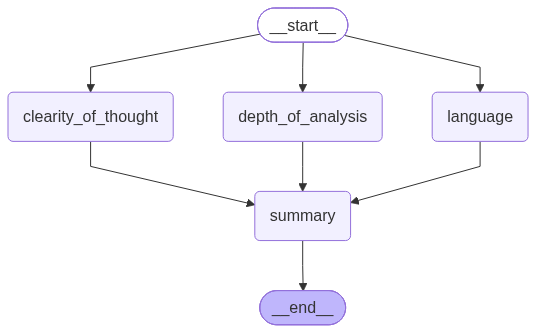

In [12]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())